In [60]:
import numpy as np
from pylab import *
from craco.cardcap import CardcapFile
from astropy.io import fits
from craft.craftcor import MiriadGainSolutions
import glob
from craco.search_pipeline import location2pix, get_grid_lut_from_plan, grid_candidates,wait_for_starts,waitall,print_candidates
from craco.search_pipeline import NBINARY_POINT_FDMTIN 
import craco
import craco.search_pipeline
from craco.pyxrtutil import *
import craft.craco_plan
from craco import cardcap

from craft import uvfits

from craft.craco_plan import PipelinePlan
from craft.craco import printstats,bl2ant
import logging
import time

%matplotlib notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
cd /data/craco/ban115/craco-python/notebooks/data/SB46776


/data/craco/ban115/craco-python/notebooks/data/SB46776


In [3]:
ls

In [80]:
f = 'b02_beam05.uvfits'
f = 'b02_beam05.uvfits.mir.uvfits' # calibrated
fits = uvfits.open(f)

In [81]:
blkiter = fits.time_blocks(256)

In [82]:
blk = next(blkiter)

In [83]:
blk = craft.craco.bl2array(blk)

In [84]:
blk = blk[:,:,0,:]

In [85]:
blk.shape

(435, 288, 256)

In [86]:

blk.dtype

dtype('complex64')

<IPython.core.display.Javascript object>


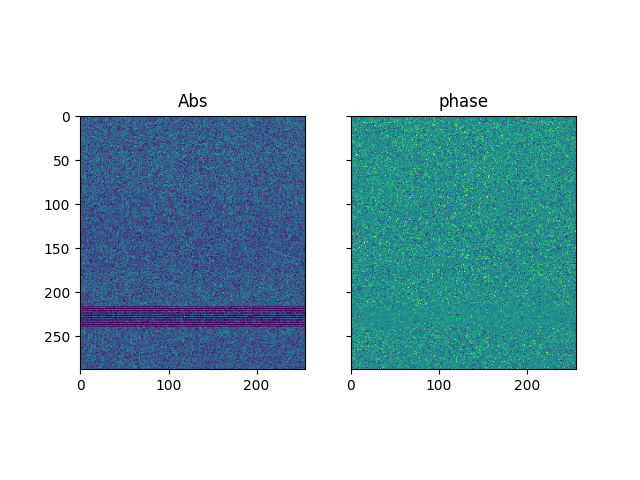

In [115]:
def plot_complex(img):
    fig, ax = subplots(1,2, sharex=True, sharey=True)
    ax[0].imshow(abs(img))
    ax[1].imshow(np.angle(img))
    ax[0].set_title('Abs')
    ax[1].set_title('phase')

plot_complex(blk[100,:,:])

In [100]:
blk.shape

(435, 288, 256)

<IPython.core.display.Javascript object>


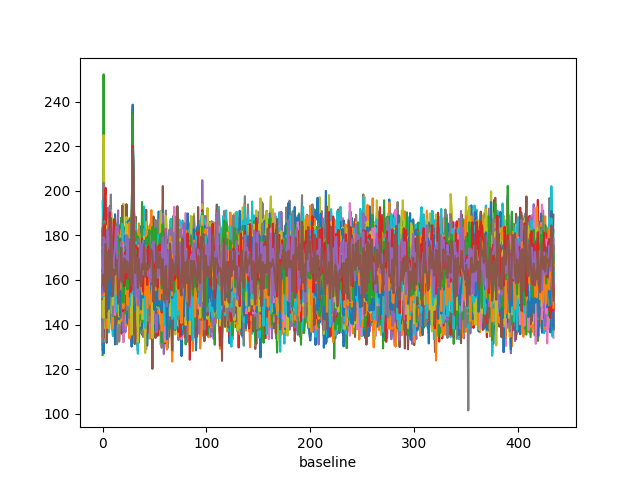

Text(0.5, 0, 'baseline')

In [132]:
favg = abs(blk.mean(axis=1))

figure()
plot(favg)
xlabel('baseline')

In [133]:
nant = 30
(products, revproducts, auto_products, cross_products) = cardcap.get_indexes(nant)

<IPython.core.display.Javascript object>


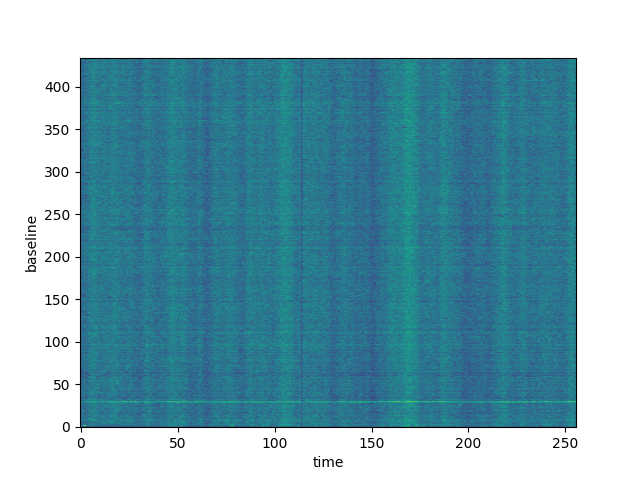

Text(0, 0.5, 'baseline')

In [134]:
figure()
imshow(favg, aspect='auto', origin='lower')
xlabel('time')
ylabel('baseline')

<IPython.core.display.Javascript object>


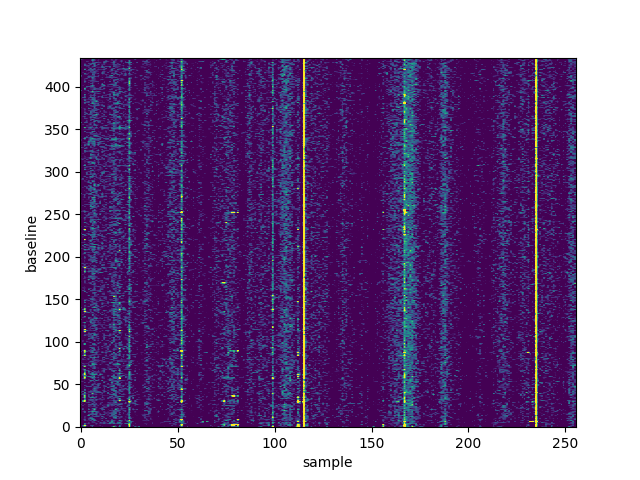

Text(0, 0.5, 'baseline')

In [106]:
figure()
imshow(favg - favg.mean(axis=1, keepdims=True), aspect='auto', origin='lower', vmin=0, vmax=30)
xlabel('sample')
ylabel('baseline')

<IPython.core.display.Javascript object>


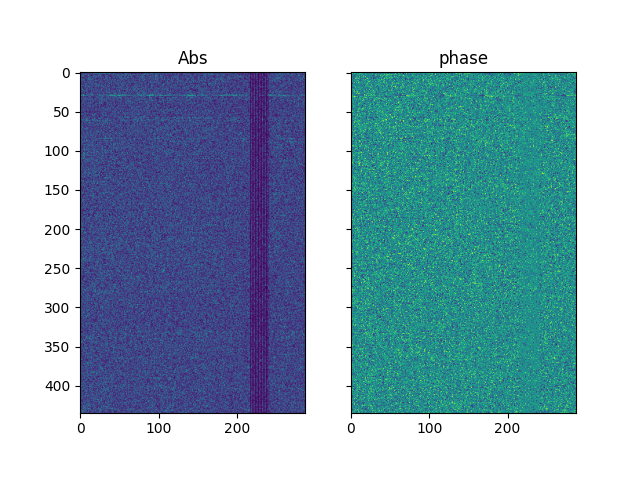

/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/numpy/ma/core.py:468: ComplexWarning: Casting complex values to real discards the imaginary part
  fill_value = np.array(fill_value, copy=False, dtype=ndtype)


In [124]:
isamp=115
blk.shape
plot_complex(blk[:,:,isamp])

<IPython.core.display.Javascript object>


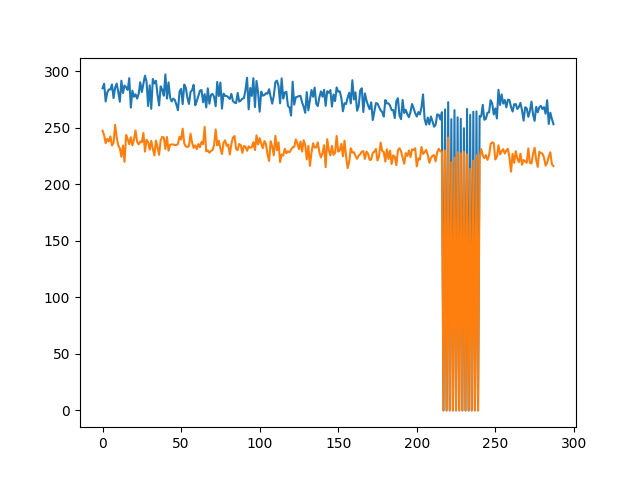

/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/numpy/ma/core.py:468: ComplexWarning: Casting complex values to real discards the imaginary part
  fill_value = np.array(fill_value, copy=False, dtype=ndtype)
/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/numpy/ma/core.py:468: ComplexWarning: Casting complex values to real discards the imaginary part
  fill_value = np.array(fill_value, copy=False, dtype=ndtype)


In [131]:
figure()
plot(abs(blk[:,:,isamp]).mean(axis=0))
plot(abs(blk[:,:,isamp+1]).mean(axis=0))

<IPython.core.display.Javascript object>


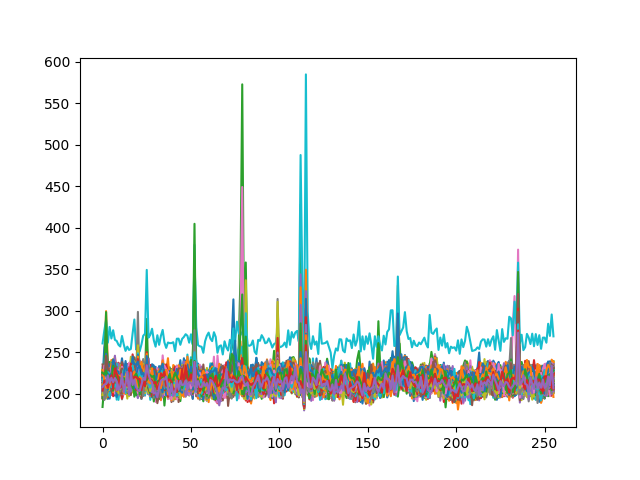

In [110]:
figure()
plot(favg.T)


In [111]:
blk.shape

(435, 288, 256)

<IPython.core.display.Javascript object>


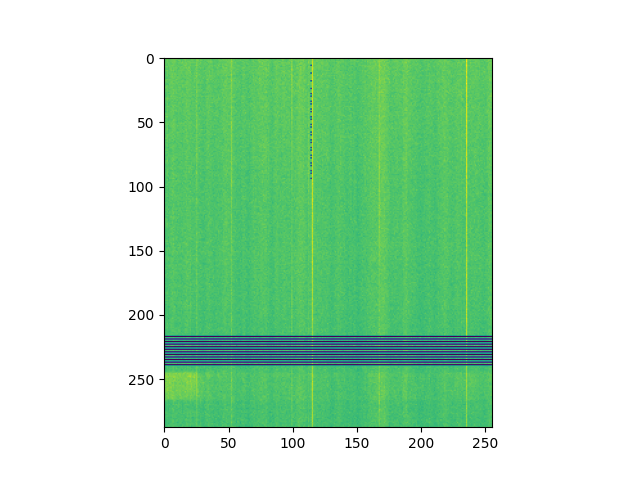

/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/numpy/ma/core.py:468: ComplexWarning: Casting complex values to real discards the imaginary part
  fill_value = np.array(fill_value, copy=False, dtype=ndtype)


In [112]:
figure()
imshow(abs(blk).mean(axis=0))

In [114]:
blk.shape

(435, 288, 256)

<IPython.core.display.Javascript object>


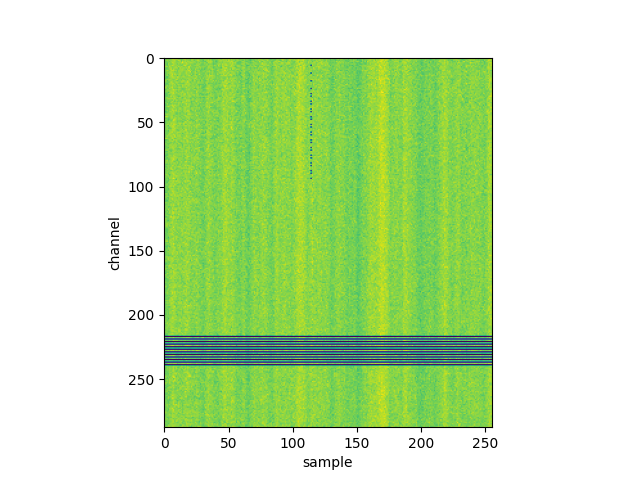

Text(0, 0.5, 'channel')

In [135]:
figure()
imshow(abs(blk.mean(axis=0)))
xlabel('sample')
ylabel('channel')

<IPython.core.display.Javascript object>


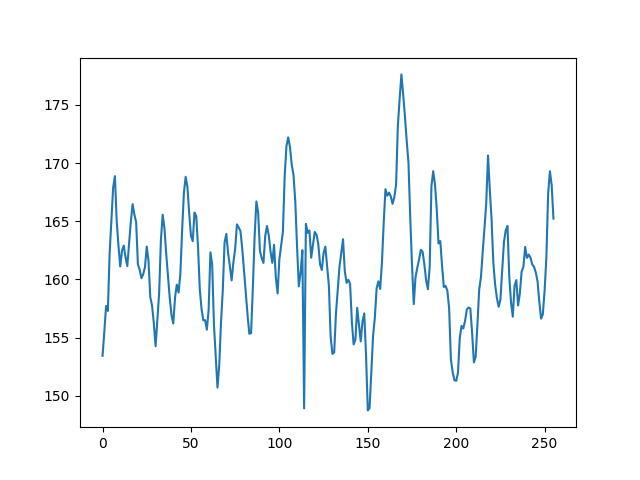

In [120]:
figure()
plot(abs(blk.mean(axis=(0,1))))